In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

plt.style.use('bmh')
plt.rcParams['axes.facecolor'] = 'white'
BATCH_SIZE = 128

2026-04-21 18:49:32.743662: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-21 18:49:32.784517: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-21 18:49:33.056643: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-21 18:49:33.059519: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-21 18:49:33.990697: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not fin

In [3]:
y = np.load('../anom-y.npy')

In [4]:
y.shape[0]

1364

In [5]:
y.shape

(1364, 25, 2)

In [6]:
from datetime import datetime
timestamps = list(pd.date_range(start=datetime(2024,11,18,0,0), end=datetime(2024,11,19,0,0), freq='60s')[51:-26])

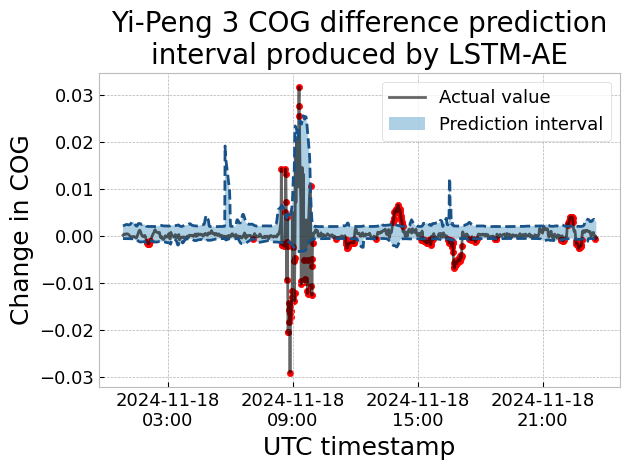

In [33]:
y_anom_low = np.load('../y_low_anom.npy')
y_anom_high = np.load('../y_high_anom.npy')

y_flat = y[:, 0, 0].ravel()
y_high = y_anom_high[:, 0].ravel()
y_low = y_anom_low[:, 0].ravel()

anomalies_x = []
anomalies_y = []
for i in range(y.shape[0]):

    if y_flat[i] < y_low[i]:
        anomalies_x.append( timestamps[i] )
        anomalies_y.append( y_flat[i] )

    elif y_flat[i] > y_high[i]:
        anomalies_x.append( timestamps[i] )
        anomalies_y.append( y_flat[i] )

plt.plot(timestamps, y[:, 0, 0].ravel(), label = "Actual value", color='black', alpha=0.6)
plt.plot(timestamps, y_anom_high[:, 0].ravel(), color='#185288', linestyle='--', linewidth=2)
plt.plot(timestamps, y_anom_low[:, 0].ravel(), color="#185288", linestyle='--')

plt.xticks(
    ticks=[datetime(2024,11,18, 3+x*6,0) for x in range(0, 4)],
    labels=[f"2024-11-18\n{(3+x*6):02}:00" for x in range(0, 4)],
)
plt.tick_params(axis='both', which='both', labelsize=13)

plt.xlabel('UTC timestamp', size=18)
plt.ylabel('Change in COG', size=18)
plt.title('Yi-Peng 3 COG difference prediction\ninterval produced by LSTM-AE', size=20)

plt.fill_between(timestamps, y1=y_anom_low[:, 0].ravel(), y2=y_anom_high[:, 0].ravel(), alpha=0.4, label='Prediction interval')
plt.scatter(anomalies_x, anomalies_y, color='red', s=20)
plt.legend(fontsize=13)

plt.tight_layout()
plt.savefig("cog-difference-res-lstm-ae.png", dpi=750)

plt.show()

In [13]:
y[:, 0, 0].ravel().shape

(1364,)

In [17]:
y_anom_high[:, 0].ravel().shape

(1364,)

In [3]:
X_train = np.load('../X_train_COGoutput.npy')
y_train = np.load('../y_train_COGoutput.npy')
X_val = np.load('../X_val_COGoutput.npy')
y_val = np.load('../y_val_COGoutput.npy')
X_test = np.load('../X_test_COGoutput.npy')
y_test = np.load('../y_test_COGoutput.npy')

# https://www.tensorflow.org/tutorials/load_data/numpy:
train_dataset = tf.data\
    .Dataset\
    .from_tensor_slices(
        (X_train, y_train)
    )\
    .batch(BATCH_SIZE)\
    .shuffle(buffer_size=10_000)

val_dataset = tf.data\
    .Dataset\
    .from_tensor_slices(
        (X_val, y_val)
    )\
    .batch(BATCH_SIZE)\
    .shuffle(buffer_size=10_000)

test_dataset = tf.data\
    .Dataset\
    .from_tensor_slices(
        (X_test, y_test)
    )\
    .batch(BATCH_SIZE)\
    .shuffle(buffer_size=10_000)

2026-03-23 12:46:48.783239: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-23 12:46:48.787357: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [4]:
import pickle

In [5]:
import tensorflow as tf
import sys
sys.path.append('..')
from src.lstm_ae_funkcijos import LSTM_AE, quantile_loss

In [6]:
model_low = LSTM_AE(
    latent_dim=5,
    lstm_units=10,
    n_out_features=y_train.shape[2],
    n_out_timesteps=y_train.shape[1],
    drop_frac=0.05
)

model_high = LSTM_AE(
    latent_dim=5,
    lstm_units=10,
    n_out_features=y_train.shape[2],
    n_out_timesteps=y_train.shape[1],
    drop_frac=0.05
)

model_low.compile(optimizer='adam', loss=quantile_loss(0.025))
model_high.compile(optimizer='adam', loss=quantile_loss(0.975))

model_low.load_weights('../lstm_ae_first_low.weights.h5')
model_high.load_weights('../lstm_ae_first_high.weights.h5')

In [7]:
X = np.load('../anom-x.npy')
y = np.load('../anom-y.npy')

In [8]:
y_high = model_high.predict(X)
y_low = model_low.predict(X)

43/43 [==============================] - 1s 2ms/step


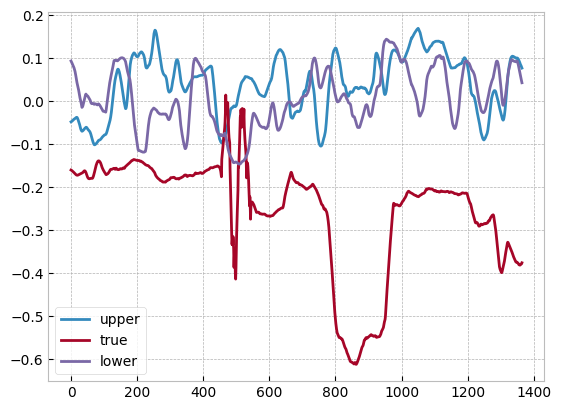

In [9]:
plt.plot( y_low[:, 0].ravel(), label='upper')
plt.plot( y[:, 0].ravel(), label='true')
plt.plot( y_high[:, 0].ravel(), label='lower')
plt.legend()

In [16]:
timestamps_not_smooth = timestamps[26:-25]
timestamps_smooth = timestamps[50:-25]

In [17]:
from datetime import datetime

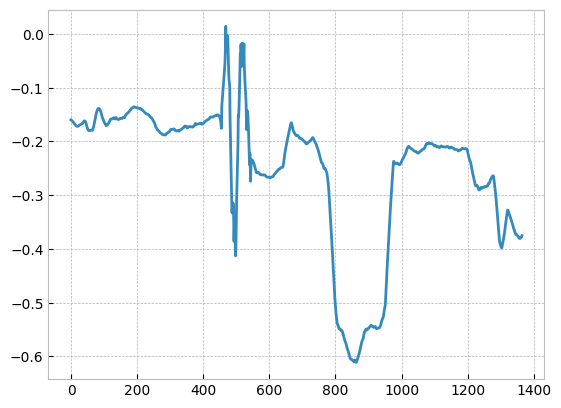

In [24]:
plt.plot(y_arr_smooth[:, 0])

NameError: name 'y_true' is not defined

In [18]:
def plot_pi(y_true, y_low, y_high, variable_name: str, timestamps: pd.Series):

    anomalies_x = []
    anomalies_y = []
    for i in range(y_true.shape[0]):

        if y_true[i] < y_low[i]:
            anomalies_x.append( timestamps[i] )
            anomalies_y.append( y_true[i] )

        elif y_true[i] > y_high[i]:
            anomalies_x.append( timestamps[i] )
            anomalies_y.append( y_true[i] )

    plt.plot(timestamps, y_low, label='Prognozės\nintervalas', lw=1, linestyle='--', color='#0D77A7')
    plt.plot(timestamps, y_high, lw=1, linestyle='--', color='#0D77A7')
    plt.fill_between(x=timestamps, y1=y_low, y2=y_high, alpha=0.2)
    plt.plot(timestamps, y_true, label='Tikroji\nreikšmė', lw=1.5, color='black')

    plt.scatter(anomalies_x, anomalies_y, color='red', label='Anomalijos')

    plt.ylabel(variable_name, size=20)
    plt.title(f'Laivo Yi-Peng 3\n{variable_name} incidento metu', size=22)

    plt.tick_params(axis='both', labelsize=18)
    plt.xticks(
        ticks=[datetime(2024, 11, 18, 0, 0), datetime(2024, 11, 18, 12, 0), datetime(2024, 11, 19, 0, 0)],
        labels=['2024-11-18\n00:00 UTC', '2024-11-18\n12:00 UTC', '2024-11-19\n00:00 UTC']
    )

    plt.legend()
    plt.tight_layout()
    plt.savefig('delta_dif_old.png', dpi=750)

    plt.show()

plot_pi(
    y_arr_smooth[:, 0, 0],
    y_low_smooth[:, 0, 0],
    y_high_smooth[:, 0, 0],
    r'$\Delta dif^*$',
    timestamps_smooth
)

IndexError: index 1364 is out of bounds for axis 0 with size 1364

In [16]:
y_low_dif[:, 0].reshape(-1)

array([ 0.00341398,  0.00418879,  0.00472241, ..., -0.00089213,
       -0.00184586, -0.01054826], dtype=float32)

In [17]:
y_high_dif.min()

np.float32(-0.600756)

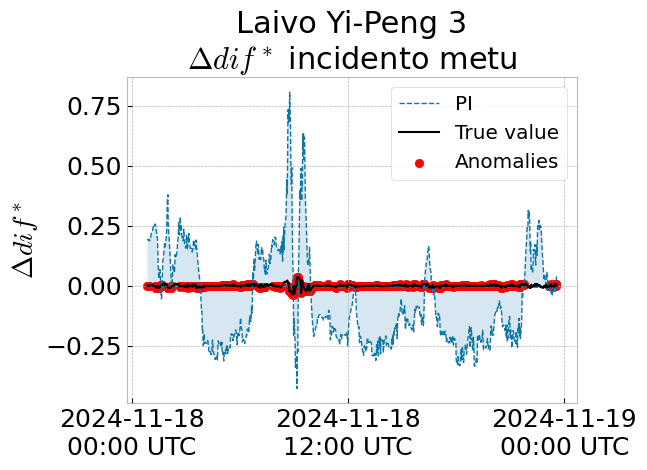

In [18]:
plot_pi(
    y_arr_smooth[:, 0, 0],
    y_low_dif[:, 1].reshape(-1),
    y_high_dif[:, 1].reshape(-1),
    r'$\Delta dif^*$',
    timestamps_smooth
)

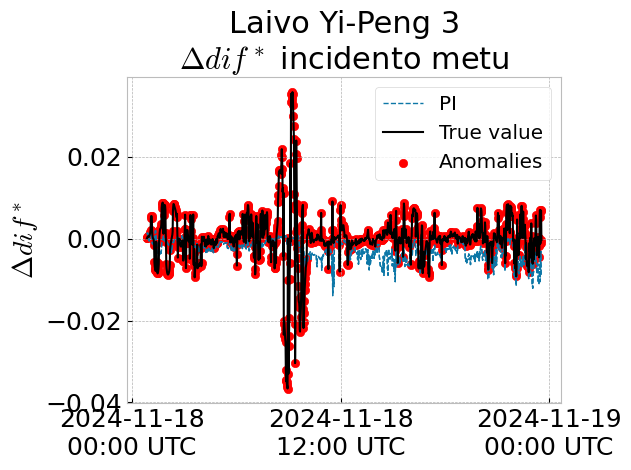

In [19]:
plot_pi(
    y_arr_smooth[:, 0, 0],
    y_low_dif[:, 1].reshape(-1),
    y_low_dif[:, 1].reshape(-1),
    r'$\Delta dif^*$',
    timestamps_smooth
)

In [20]:
plot_pi(
    y_arr_not_smooth[:, 0, 0],
    y_low_not_smooth[:, 0, 0],
    y_high_not_smooth[:, 0, 0],
    r'$\Delta dif^*$',
    timestamps_not_smooth
)

NameError: name 'y_low_not_smooth' is not defined

In [ ]:
np.mean( quantile_loss(0.025)( y_arr_smooth, y_low_smooth ) )

np.float64(0.029002030274781116)

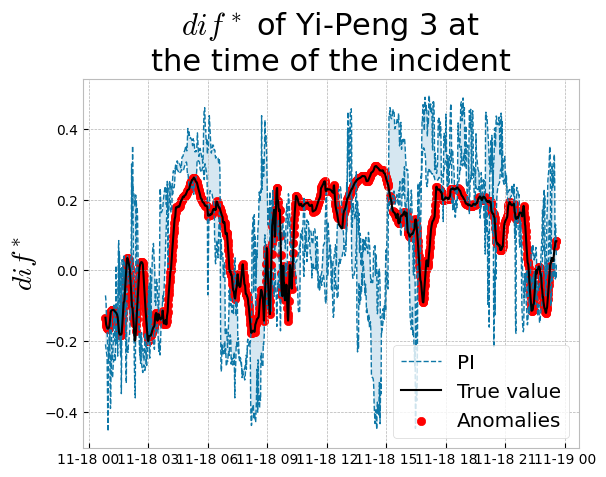

In [ ]:
plot_pi(
    y_arr_smooth[:, 24, 1],
    y_low_smooth[:, 24, 1],
    y_high_smooth[:, 24, 1],
    r'$dif^*$',
    timestamps_smooth
)

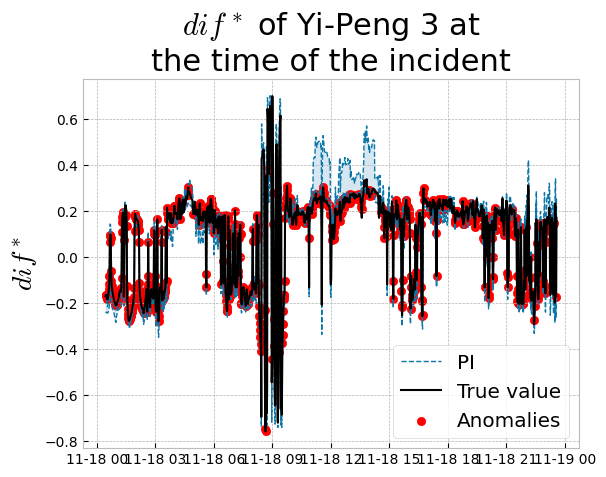

In [ ]:
plot_pi(
    y_arr_not_smooth[:, 0, 1],
    y_low_not_smooth[:, 0, 1],
    y_high_not_smooth[:, 0, 1],
    r'$dif^*$',
    timestamps_not_smooth
)

- Heading ir COG skiriasi matavimo tikslumas
- Pabandyti su moving average
- Pažiūrėti, kiek duomenų interpoliuota, koks pasiskirstymas


MMSI: 304473000 (HAV Dolphin), 311014800 (HAV Snapper)